In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

## 1. PINN Architecture Definition
Definition of the standard Neural Network (Multi-Layer Perceptron) to approximate the solution $u(t,x)$ containing the trainable parameter `alpha`.

In [2]:
class PinnHeatEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 50)
        self.couche_cachee1 = nn.Linear(50, 50)
        self.couche_cachee2 = nn.Linear(50, 50)
        self.couche_sortie = nn.Linear(50, 1)

    def forward(self, x):
        x = torch.tanh(self.couche_entree(x))
        x = torch.tanh(self.couche_cachee1(x))
        x = torch.tanh(self.couche_cachee2(x))
        return self.couche_sortie(x)

def A(t, x):
    return torch.sin(2 * torch.pi * x)

def B(t, x):
    return t * x * (1 - x)

class SolutionHard(nn.Module):
    def __init__(self, reseau):
        super().__init__()
        self.reseau = reseau
        # THE INVERSE PARAMETER: initialized to 0.01
        self.alpha = nn.Parameter(torch.tensor([0.01], dtype=torch.float32))

    def forward(self, entrees):
        t, x = entrees[:, :1], entrees[:, 1:]
        return A(t, x) + B(t, x) * self.reseau(entrees)

## 2. Sampling, Collocation, and Observation Points Generation
Functions to generate collocation points (in the domain), initial points ($t=0$), boundary points ($x=0$ and $x=1$), and synthetic observation data used for identifying $\alpha$.

In [3]:
t_min, t_max = 0.0, 1.0
x_min, x_max = -1.0, 1.0


def generer_points_collocation(n_pde):
    t_colloc = torch.rand(n_pde, 1) * (t_max - t_min) + t_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return t_colloc.float(), x_colloc.float()


# Synthetic observation data generation (with measurement noise)
t_data = torch.rand(400, 1)
x_data = torch.rand(400, 1) * (x_max - x_min) + x_min
inputs_data = torch.cat([t_data, x_data], dim=1)
alpha_vrai = 0.0005
u_vrai = torch.exp(-alpha_vrai * 4 * (torch.pi**2) * t_data) * torch.sin(2 * torch.pi * x_data)
noise_level = 0.10  # Gaussian noise, 10% of the signal std
u_data = u_vrai + noise_level * u_vrai.std() * torch.randn_like(u_vrai)

## 3. Loss Function Definition
Definition of the global loss function combining the PDE residual (CLP) and the gap with the observation data (boundary and initial conditions being verified by construction of the Hard model).

In [4]:
def calc_clp_loss(model, t_colloc, x_colloc, alpha, u_data):
    t_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    u_pred = model(torch.cat([t_colloc, x_colloc], dim=1))

    u_t = torch.autograd.grad(
        outputs=u_pred,
        inputs=t_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_x = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]
    
    u_pred_data = model(inputs_data)
    loss_data = torch.mean((u_pred_data - u_data) ** 2)

    residu = u_t - alpha * u_xx
    return torch.mean(residu ** 2) + loss_data

## 4. Hardware (Device), Model, and Data Initialization
Hardware detection, inverse model creation, definition of the Adam optimizer with two distinct learning rates (parameter group for `alpha`), and transfer of points to the device.

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

reseau = PinnHeatEq().to(device)
modele = SolutionHard(reseau).to(device)

# Adam optimizer with distinct learning rates
optimizer = optim.Adam([
    {'params': modele.reseau.parameters(), 'lr': 0.001},
    {'params': [modele.alpha], 'lr': 0.02} # larger lr for alpha
])

t_colloc, x_colloc = generer_points_collocation(12000)
t_colloc, x_colloc = t_colloc.to(device), x_colloc.to(device)

inputs_data = inputs_data.to(device)
u_data = u_data.to(device)

cuda


## 5. Model Training (Adam)
Training phase of the inverse problem with the Adam optimizer to identify the physical parameter $\alpha$.

In [6]:
epochs = 3000

print("--- INVERSE PROBLEM TRAINING WITH ADAM ---")
for epoch in range(epochs):
    optimizer.zero_grad()

    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, modele.alpha, u_data)
    loss_clp.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:05d} | CLP: {loss_clp.item():.2e} | Alpha estimate: {modele.alpha.item():.2e}")

--- INVERSE PROBLEM TRAINING WITH ADAM ---
Epoch 00000 | CLP: 1.78e-01 | Alpha estimate: -1.00e-02
Epoch 00100 | CLP: 4.69e-03 | Alpha estimate: -1.88e-05
Epoch 00200 | CLP: 4.69e-03 | Alpha estimate: -6.20e-06
Epoch 00300 | CLP: 4.68e-03 | Alpha estimate: -2.69e-06
Epoch 00400 | CLP: 4.68e-03 | Alpha estimate: 1.59e-06
Epoch 00500 | CLP: 4.68e-03 | Alpha estimate: 6.18e-06
Epoch 00600 | CLP: 4.67e-03 | Alpha estimate: 1.09e-05
Epoch 00700 | CLP: 4.67e-03 | Alpha estimate: 1.57e-05
Epoch 00800 | CLP: 4.67e-03 | Alpha estimate: 2.03e-05
Epoch 00900 | CLP: 4.67e-03 | Alpha estimate: 2.45e-05
Epoch 01000 | CLP: 4.67e-03 | Alpha estimate: 2.82e-05
Epoch 01100 | CLP: 4.67e-03 | Alpha estimate: 3.16e-05
Epoch 01200 | CLP: 4.67e-03 | Alpha estimate: 3.46e-05
Epoch 01300 | CLP: 4.67e-03 | Alpha estimate: 3.75e-05
Epoch 01400 | CLP: 7.05e-03 | Alpha estimate: -1.40e-03
Epoch 01500 | CLP: 4.67e-03 | Alpha estimate: 3.22e-05
Epoch 01600 | CLP: 4.66e-03 | Alpha estimate: 4.48e-05
Epoch 01700 | CLP

## 6. Visualizing the Results
Comparison of the solution learned by the PINN with the exact analytical solution of the heat equation.

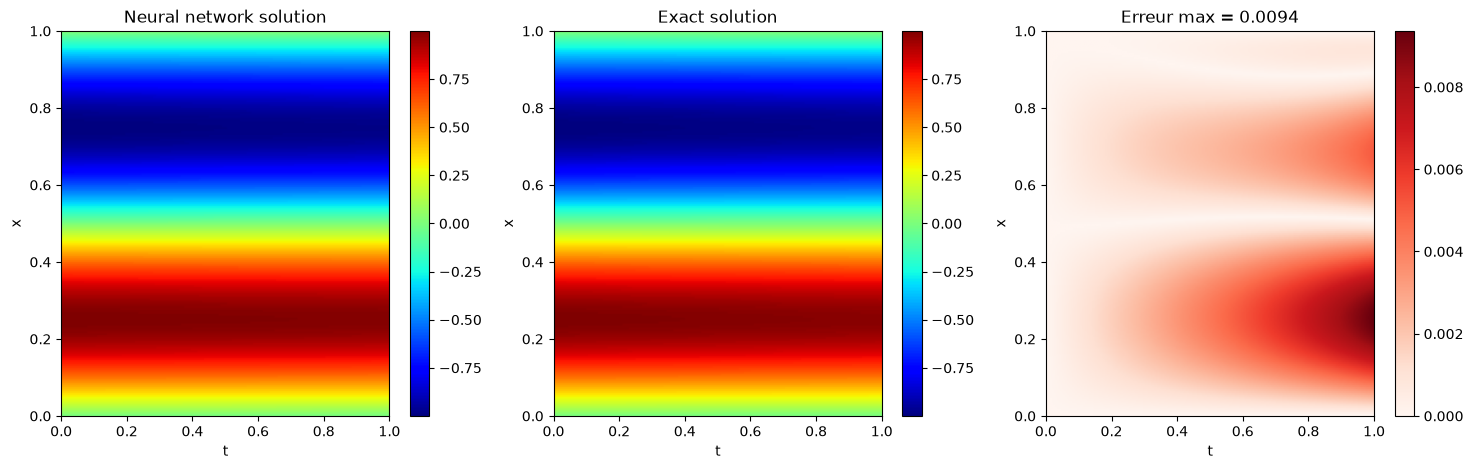

In [7]:
import sys; sys.path.append("..")
import numpy as np                                                                                                    
from pinnplot import plot_solution                        

u_exact = lambda t, x: np.sin(2*np.pi*x) * np.exp(-(2*np.pi)**2 * alpha_vrai * t)

plot_solution(modele, u_exact)

## Bonus Section: Alternative Comparison (Separate Adam + SGD)
Alternative comparison cell using separate Adam (Network) and SGD (Alpha) with gradient clipping to prevent NaN at startup.

In [8]:
# Clean re-instantiation
reseau_sol2 = PinnHeatEq().to(device)
modele_sol2 = SolutionHard(reseau_sol2).to(device)

# Two separate optimizers
optimizer_net = optim.Adam(modele_sol2.reseau.parameters(), lr=0.001)
optimizer_alpha = optim.SGD([modele_sol2.alpha], lr=0.005) # SGD with moderate lr for alpha

epochs = 3000
print("--- TRAINING SOLUTION 2 (Separate Adam + SGD) ---")
for epoch in range(epochs):
    optimizer_net.zero_grad()
    optimizer_alpha.zero_grad()
    
    loss_clp = calc_clp_loss(modele_sol2, t_colloc, x_colloc, modele_sol2.alpha, u_data)
    loss_clp.backward()
    
    # Gradient clipping to prevent divergence to NaN
    torch.nn.utils.clip_grad_value_([modele_sol2.alpha], clip_value=0.1)
    
    optimizer_net.step()
    optimizer_alpha.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:05d} | CLP: {loss_clp.item():.2e} | Alpha estimate: {modele_sol2.alpha.item():.2e}")

--- TRAINING SOLUTION 2 (Separate Adam + SGD) ---
Epoch 00000 | CLP: 8.02e-02 | Alpha estimate: 9.50e-03
Epoch 00100 | CLP: 4.71e-03 | Alpha estimate: -3.24e-04
Epoch 00200 | CLP: 4.71e-03 | Alpha estimate: -3.24e-04
Epoch 00300 | CLP: 4.70e-03 | Alpha estimate: -3.24e-04
Epoch 00400 | CLP: 4.70e-03 | Alpha estimate: -3.24e-04
Epoch 00500 | CLP: 4.70e-03 | Alpha estimate: -3.24e-04
Epoch 00600 | CLP: 4.70e-03 | Alpha estimate: -3.24e-04
Epoch 00700 | CLP: 4.70e-03 | Alpha estimate: -3.24e-04
Epoch 00800 | CLP: 4.69e-03 | Alpha estimate: -3.24e-04
Epoch 00900 | CLP: 4.69e-03 | Alpha estimate: -3.24e-04
Epoch 01000 | CLP: 4.69e-03 | Alpha estimate: -3.24e-04
Epoch 01100 | CLP: 4.69e-03 | Alpha estimate: -3.24e-04
Epoch 01200 | CLP: 4.69e-03 | Alpha estimate: -3.24e-04
Epoch 01300 | CLP: 4.69e-03 | Alpha estimate: -3.24e-04
Epoch 01400 | CLP: 4.69e-03 | Alpha estimate: -3.24e-04
Epoch 01500 | CLP: 4.69e-03 | Alpha estimate: -3.24e-04
Epoch 01600 | CLP: 4.69e-03 | Alpha estimate: -3.24e-04